<a href="https://colab.research.google.com/github/dmitrijprilepa/pattern-recognition-practice/blob/main/notebooks/PR01_Prylepa_D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практична робота 1

## Google Colab, GitHub і перше знайомство з даними

**Дисципліна:** Розпізнавання образів і машинне навчання  
**Студент:** <прізвище, ім’я>  
**Група:** <назва групи>  
**Дата виконання:** <дата>

### Мета роботи

Ознайомитися із середовищем Google Colab, структурою ML-проєкту,
сервісом GitHub і базовими операціями аналізу табличних даних.
Замість тексту в кутових дужках введіть власні дані.



## 1. Підключення бібліотек

На цьому етапі підключаються бібліотеки для роботи з таблицями,
числовими масивами, графіками та наборами даних машинного навчання.


In [47]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from sklearn.datasets import load_iris
from IPython.display import display


In [48]:
print("Версія Python:", sys.version.split()[0])
print("Версія NumPy:", np.__version__)
print("Версія pandas:", pd.__version__)
print("Версія scikit-learn:", sklearn.__version__)


Версія Python: 3.12.13
Версія NumPy: 2.0.2
Версія pandas: 2.2.2
Версія scikit-learn: 1.6.1


## 2. Підключення Google Drive

Google Drive використовується для постійного зберігання наборів даних
і результатів роботи. Файли у тимчасовій пам’яті Colab можуть бути
видалені після завершення сеансу.


In [49]:
from google.colab import drive

drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [50]:
PROJECT_DIR = Path("/content/drive/MyDrive/pattern-recognition-practice")

DATA_DIR = PROJECT_DIR / "data"
NOTEBOOKS_DIR = PROJECT_DIR / "notebooks"
REPORTS_DIR = PROJECT_DIR / "reports"

DATA_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOKS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Робоча папка:", PROJECT_DIR)
print("Папка даних:", DATA_DIR)
print("Папка Notebook:", NOTEBOOKS_DIR)
print("Папка звітів:", REPORTS_DIR)


Робоча папка: /content/drive/MyDrive/pattern-recognition-practice
Папка даних: /content/drive/MyDrive/pattern-recognition-practice/data
Папка Notebook: /content/drive/MyDrive/pattern-recognition-practice/notebooks
Папка звітів: /content/drive/MyDrive/pattern-recognition-practice/reports


In [51]:
for path in PROJECT_DIR.iterdir():
    print(path.name)


data
notebooks
reports


## 3. Завантаження набору даних

У роботі використовується навчальний набір Iris із бібліотеки
scikit-learn. Він містить вимірювання квіток трьох видів ірису.


In [52]:
iris = load_iris(as_frame=True)

print(type(iris))
print(iris.keys())


<class 'sklearn.utils._bunch.Bunch'>
dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [53]:
print("Назви ознак:")
for feature_name in iris.feature_names:
    print("-", feature_name)

print("\nНазви класів:")
for target_name in iris.target_names:
    print("-", target_name)


Назви ознак:
- sepal length (cm)
- sepal width (cm)
- petal length (cm)
- petal width (cm)

Назви класів:
- setosa
- versicolor
- virginica


In [54]:
df = iris.frame.copy()

display(df.head())


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [55]:
print(df["target"].value_counts().sort_index())

target
0    50
1    50
2    50
Name: count, dtype: int64


In [56]:
target_mapping = {
    0: "setosa",
    1: "versicolor",
    2: "virginica"
}

print(target_mapping)


{0: 'setosa', 1: 'versicolor', 2: 'virginica'}


In [57]:
df["species"] = df["target"].map(target_mapping)



In [58]:
df = df.drop(columns=["target"])

In [59]:
df = df.rename(
    columns={
        "sepal length (cm)": "sepal_length_cm",
        "sepal width (cm)": "sepal_width_cm",
        "petal length (cm)": "petal_length_cm",
        "petal width (cm)": "petal_width_cm"
    }
)

display(df.head())


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 4. Збереження даних у форматі CSV

Підготовлена таблиця зберігається на Google Drive, після чого
повторно завантажується засобами бібліотеки pandas.


In [60]:
CSV_PATH = DATA_DIR / "iris.csv"

df.to_csv(CSV_PATH, index=False)

print("Файл збережено:")
print(CSV_PATH)


Файл збережено:
/content/drive/MyDrive/pattern-recognition-practice/data/iris.csv


In [61]:
if CSV_PATH.exists():
    print("Файл успішно створено.")
    print("Розмір файла:", CSV_PATH.stat().st_size, "байт")
else:
    print("Файл не знайдено.")


Файл успішно створено.
Розмір файла: 3870 байт


## 5. Читання табличних даних

Для читання CSV-файла використовується функція `pandas.read_csv()`.
Результатом є об’єкт типу DataFrame.


In [62]:
data = pd.read_csv(CSV_PATH)

print("Тип об’єкта:", type(data))


Тип об’єкта: <class 'pandas.core.frame.DataFrame'>


In [63]:
display(data.head())


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [64]:
display(data.head(10))

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [65]:
display(data.tail())

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [66]:
print("Розмір таблиці:", data.shape)
print("Кількість об’єктів:", data.shape[0])
print("Кількість стовпців:", data.shape[1])


Розмір таблиці: (150, 5)
Кількість об’єктів: 150
Кількість стовпців: 5


In [67]:
print("Назви стовпців:")

for column in data.columns:
    print("-", column)


Назви стовпців:
- sepal_length_cm
- sepal_width_cm
- petal_length_cm
- petal_width_cm
- species


In [68]:
print(data.dtypes)


sepal_length_cm    float64
sepal_width_cm     float64
petal_length_cm    float64
petal_width_cm     float64
species             object
dtype: object


In [69]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sepal_length_cm  150 non-null    float64
 1   sepal_width_cm   150 non-null    float64
 2   petal_length_cm  150 non-null    float64
 3   petal_width_cm   150 non-null    float64
 4   species          150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [70]:
missing_values = data.isna().sum()

print("Кількість пропущених значень:")
print(missing_values)


Кількість пропущених значень:
sepal_length_cm    0
sepal_width_cm     0
petal_length_cm    0
petal_width_cm     0
species            0
dtype: int64


In [71]:
print("Загальна кількість пропусків:", data.isna().sum().sum())

Загальна кількість пропусків: 0


In [72]:
duplicate_count = data.duplicated().sum()

print("Кількість повністю однакових рядків:", duplicate_count)


Кількість повністю однакових рядків: 1


In [73]:
print("Кількість унікальних значень у кожному стовпці:")
print(data.nunique())


Кількість унікальних значень у кожному стовпці:
sepal_length_cm    35
sepal_width_cm     23
petal_length_cm    43
petal_width_cm     22
species             3
dtype: int64


In [74]:
structure_summary = pd.DataFrame(
    {
        "data_type": data.dtypes.astype(str),
        "missing_values": data.isna().sum(),
        "unique_values": data.nunique()
    }
)

display(structure_summary)


,data_type,missing_values,unique_values
sepal_length_cm,float64,0,35
sepal_width_cm,float64,0,23
petal_length_cm,float64,0,43
petal_width_cm,float64,0,22
species,object,0,3


In [75]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=structure_summary)

https://docs.google.com/spreadsheets/d/1EDGPK6mY8uJT3HZb05vdeltmM4NP3CvtejL9nAcRnm8/edit#gid=0


In [76]:
numeric_statistics = data.describe().T

display(numeric_statistics)


,count,mean,std,min,25%,50%,75%,max
sepal_length_cm,150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal_width_cm,150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal_length_cm,150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal_width_cm,150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5


In [77]:
class_counts = data["species"].value_counts()

display(class_counts.rename("count").to_frame())



,count
species,
setosa,50
versicolor,50
virginica,50


In [78]:
class_percentages = (
    data["species"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(class_percentages.rename("percentage").to_frame())

,percentage
species,
setosa,33.33
versicolor,33.33
virginica,33.33


## 6. Візуалізація даних

Гістограми використовуються для первинного дослідження розподілів
числових ознак.


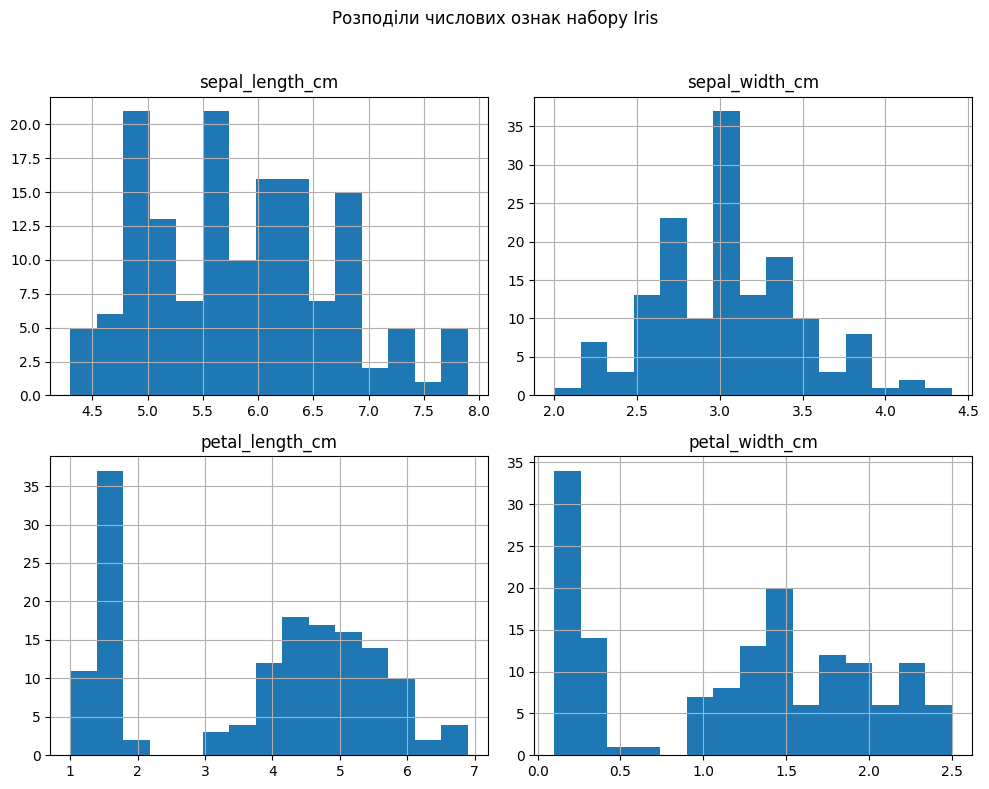

In [79]:
feature_columns = [
    "sepal_length_cm",
    "sepal_width_cm",
    "petal_length_cm",
    "petal_width_cm"
]

data[feature_columns].hist(
    bins=15,
    figsize=(10, 8)
)

plt.suptitle("Розподіли числових ознак набору Iris")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


Після графіків додайте текстову комірку та дайте відповіді:
1.	Яка ознака має найменші значення?
2.	Яка ознака має найбільший діапазон?
3.	Чи всі розподіли мають однакову форму?
4.	Для яких ознак можна помітити кілька груп значень?


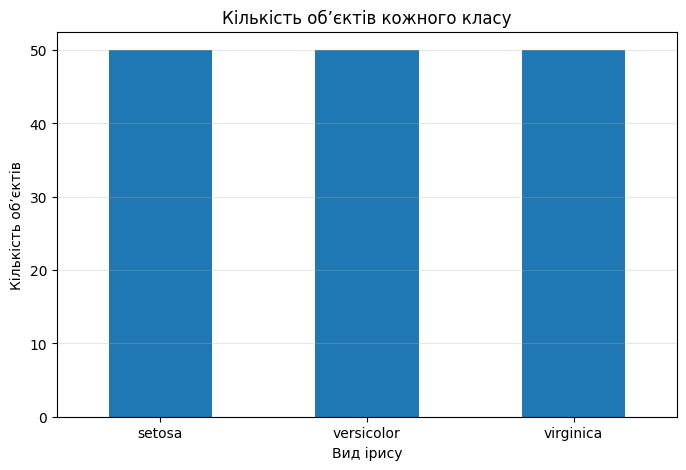

In [80]:
class_counts = data["species"].value_counts().sort_index()

class_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Кількість об’єктів кожного класу")
plt.xlabel("Вид ірису")
plt.ylabel("Кількість об’єктів")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()


У висновку потрібно зазначити, чи містять класи приблизно однакову кількість об’єктів.

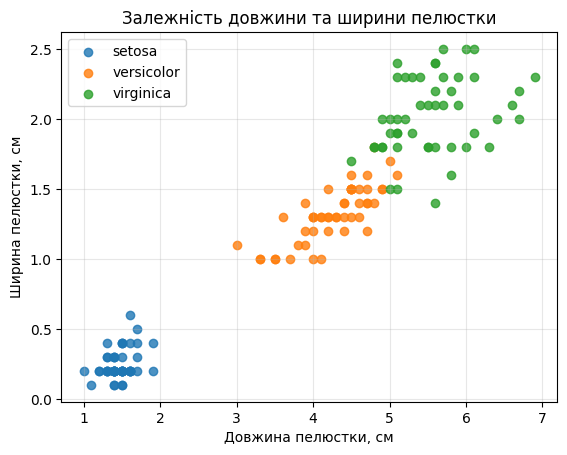

In [81]:
for species_name, group in data.groupby("species"):
    plt.scatter(
        group["petal_length_cm"],
        group["petal_width_cm"],
        label=species_name,
        alpha=0.8
    )

plt.title("Залежність довжини та ширини пелюстки")
plt.xlabel("Довжина пелюстки, см")
plt.ylabel("Ширина пелюстки, см")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 7. Постановка задачі машинного навчання

### Об’єкт дослідження

Одним об’єктом є одна квітка ірису, для якої виміряно
характеристики чашолистка та пелюстки.

### Ознаки

Використовуються чотири числові ознаки:

1. довжина чашолистка;
2. ширина чашолистка;
3. довжина пелюстки;
4. ширина пелюстки.

### Цільова змінна

Цільовою змінною є `species` – вид квітки ірису.

### Тип задачі

Задача належить до навчання з учителем і є задачею
багатокласової класифікації.

### Формулювання задачі

Необхідно за чотирма числовими характеристиками квітки
автоматично визначити, до якого з трьох видів ірису вона належить:
setosa, versicolor або virginica.



In [82]:
X = data.drop(columns=["species"])
y = data["species"]

print("Розмір матриці ознак X:", X.shape)
print("Розмір цільової змінної y:", y.shape)


Розмір матриці ознак X: (150, 4)
Розмір цільової змінної y: (150,)


In [83]:
display(X.head())

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [84]:
display(y.head())

,species
0,setosa
1,setosa
2,setosa
3,setosa
4,setosa


In [85]:
expected_columns = {
    "sepal_length_cm",
    "sepal_width_cm",
    "petal_length_cm",
    "petal_width_cm",
    "species"
}

assert data.shape == (150, 5), (
    f"Очікувався розмір (150, 5), отримано {data.shape}"
)

assert set(data.columns) == expected_columns, (
    "Назви стовпців не відповідають очікуваним."
)

assert data.isna().sum().sum() == 0, (
    "У таблиці знайдено пропущені значення."
)

assert data["species"].nunique() == 3, (
    "Очікувалося три класи."
)

assert set(data["species"].unique()) == {
    "setosa",
    "versicolor",
    "virginica"
}, "Назви класів не відповідають очікуваним."

print("Усі основні перевірки виконано успішно.")


Усі основні перевірки виконано успішно.


# Висновки
Під час виконання практичної роботи було створено GitHub-репозиторій
для зберігання матеріалів курсу та сформовано базову структуру
ML-проєкту.
У середовищі Google Colab було підключено бібліотеки NumPy, pandas,
Matplotlib і scikit-learn, а також підключено Google Drive.
Для дослідження використано набір даних Iris, який містить 150
об’єктів, чотири числові ознаки та одну цільову категоріальну змінну.
Об’єктом дослідження є квітка ірису, а цільовою змінною – її вид.
Під час первинного аналізу було визначено розмір таблиці, назви
стовпців, типи даних, кількість пропущених значень і основні
статистичні характеристики. Також було побудовано гістограми ознак,
діаграму кількості об’єктів кожного класу та діаграму залежності
довжини й ширини пелюстки.
Встановлено, що досліджувана задача є задачею багатокласової
класифікації: за чотирма числовими ознаками необхідно визначити
один із трьох видів ірису.
